### import necessary libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from warnings import filterwarnings
filterwarnings('ignore')

Loading and inspecting the data

In [2]:
df = pd.read_csv('iris.csv',index_col='Id')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.shape

(150, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [5]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


we have some indication of outliers in petal length and petal width we will discover it later

In [6]:
df.isna().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

### Visualization and EDA

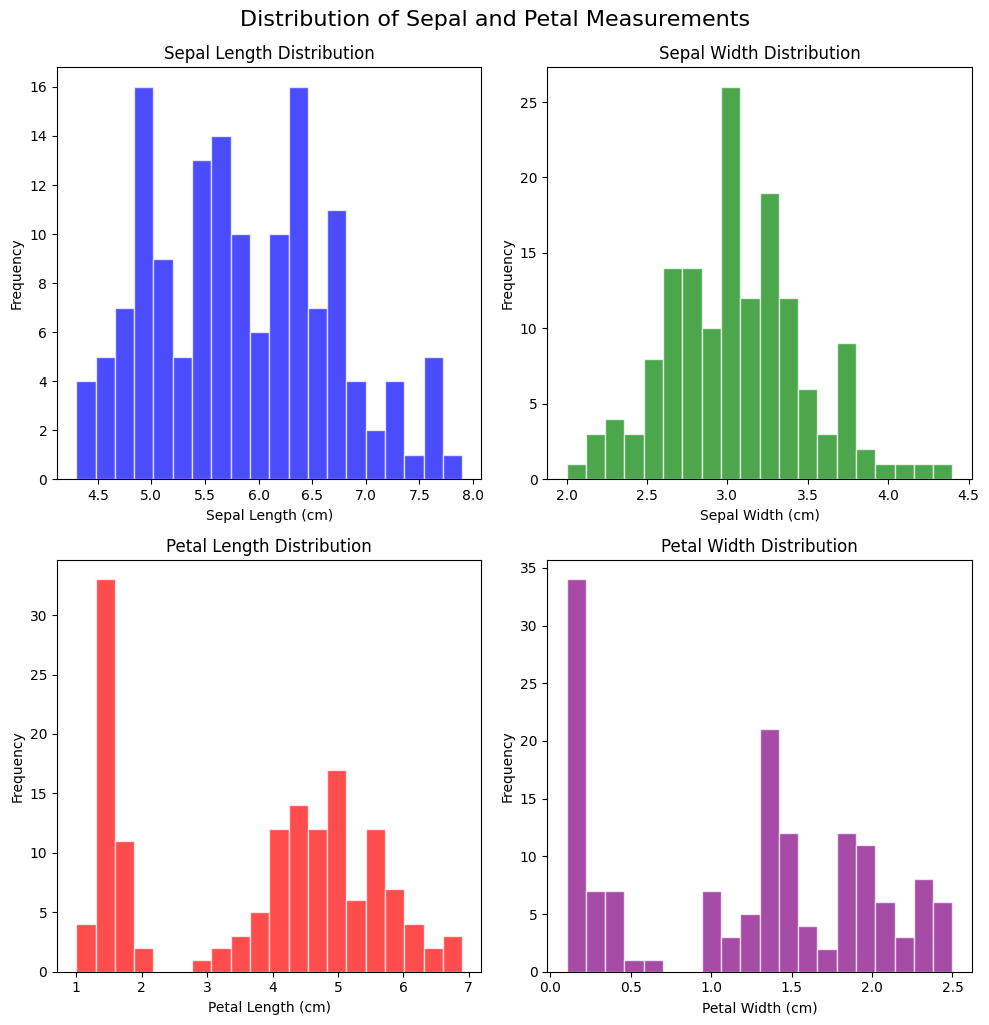

In [7]:
fig,axes=plt.subplots(2,2,figsize=(10,10))

axes[0,0].hist(df['SepalLengthCm'],bins=20,color='blue',alpha=0.7,edgecolor='white')
axes[0,0].set_title('Sepal Length Distribution')
axes[0,0].set_xlabel('Sepal Length (cm)')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(df['SepalWidthCm'],bins=20,color='green',alpha=0.7,edgecolor='white')
axes[0,1].set_title('Sepal Width Distribution')
axes[0,1].set_xlabel('Sepal Width (cm)')
axes[0,1].set_ylabel('Frequency')

axes[1,0].hist(df['PetalLengthCm'],bins=20,color='red',alpha=0.7,edgecolor='white')
axes[1,0].set_title('Petal Length Distribution')
axes[1,0].set_xlabel('Petal Length (cm)')
axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(df['PetalWidthCm'],bins=20,color='purple',alpha=0.7,edgecolor='white')
axes[1,1].set_title('Petal Width Distribution')
axes[1,1].set_xlabel('Petal Width (cm)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Distribution of Sepal and Petal Measurements', fontsize=16, y=1.02)
plt.show()

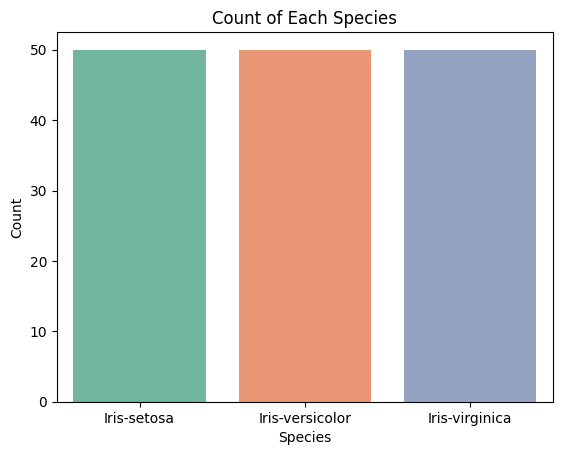

In [8]:
sns.countplot(x='Species', data=df, palette='Set2',legend=False,hue='Species')
plt.title('Count of Each Species')
plt.ylabel('Count')
plt.xlabel('Species')
plt.show()

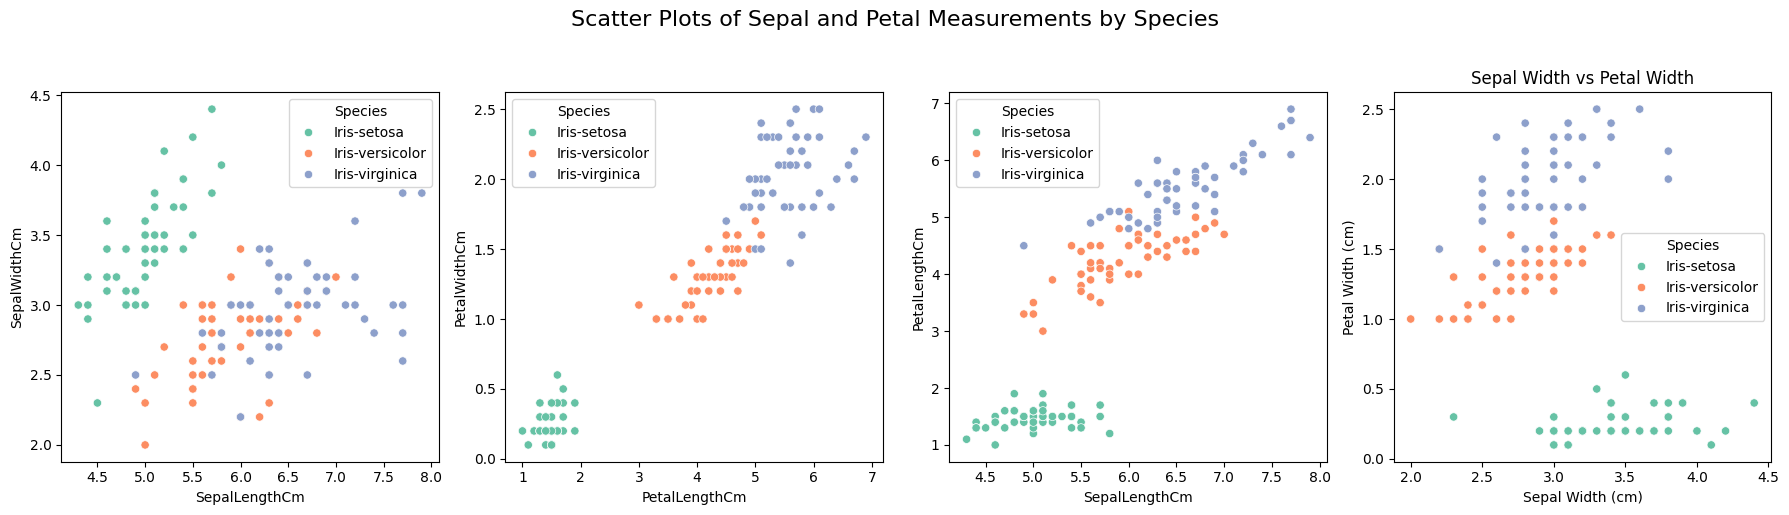

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sns.scatterplot(data=df,x='SepalLengthCm', y='SepalWidthCm', hue='Species', palette='Set2',ax=axes[0])
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')

sns.scatterplot(data=df,x='PetalLengthCm', y='PetalWidthCm', hue='Species', palette='Set2',ax=axes[1])
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')

sns.scatterplot(data=df,x='SepalLengthCm', y='PetalLengthCm', hue='Species', palette='Set2',ax=axes[2])
plt.title('Sepal Length vs Petal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')

sns.scatterplot(data=df,x='SepalWidthCm', y='PetalWidthCm', hue='Species', palette='Set2',ax=axes[3])
plt.title('Sepal Width vs Petal Width')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Petal Width (cm)')

plt.suptitle('Scatter Plots of Sepal and Petal Measurements by Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

petal length, sepal length and width have positive relation ship with iris versicolor and virginica and will take a look at this later

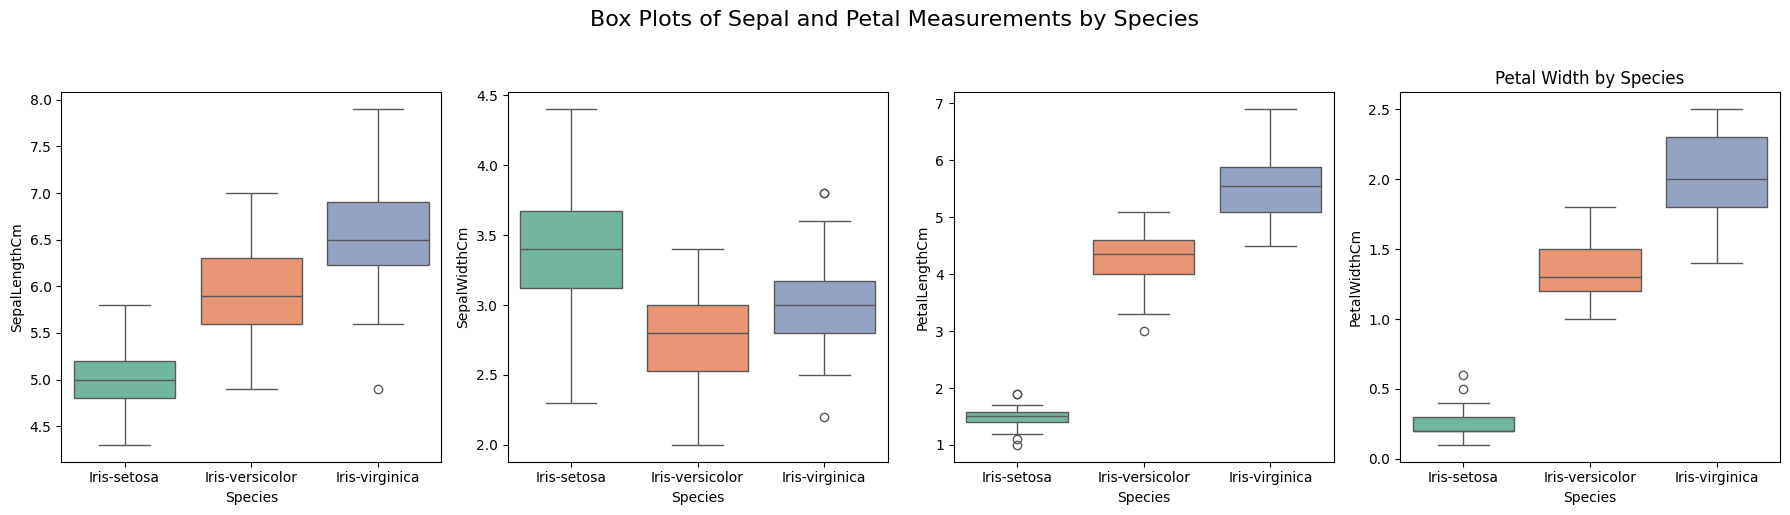

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
sns.boxplot(x='Species', y='SepalLengthCm', data=df, ax=axes[0], palette='Set2',hue='Species')
plt.title('Sepal Length by Species')

sns.boxplot(x='Species', y='SepalWidthCm', data=df, ax=axes[1], palette='Set2',hue='Species')
plt.title('Sepal Width by Species')

sns.boxplot(x='Species', y='PetalLengthCm', data=df, ax=axes[2], palette='Set2',hue='Species')
plt.title('Petal Length by Species')

sns.boxplot(x='Species', y='PetalWidthCm', data=df, ax=axes[3], palette='Set2',hue='Species')
plt.title('Petal Width by Species')

plt.suptitle('Box Plots of Sepal and Petal Measurements by Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


here we have some little outliers in the data for the 4 features, but we will ignore them as they are very small and our dataset is very small

finally, we can create a pairplot to visualize the relationships between the features and how they relate to the species.

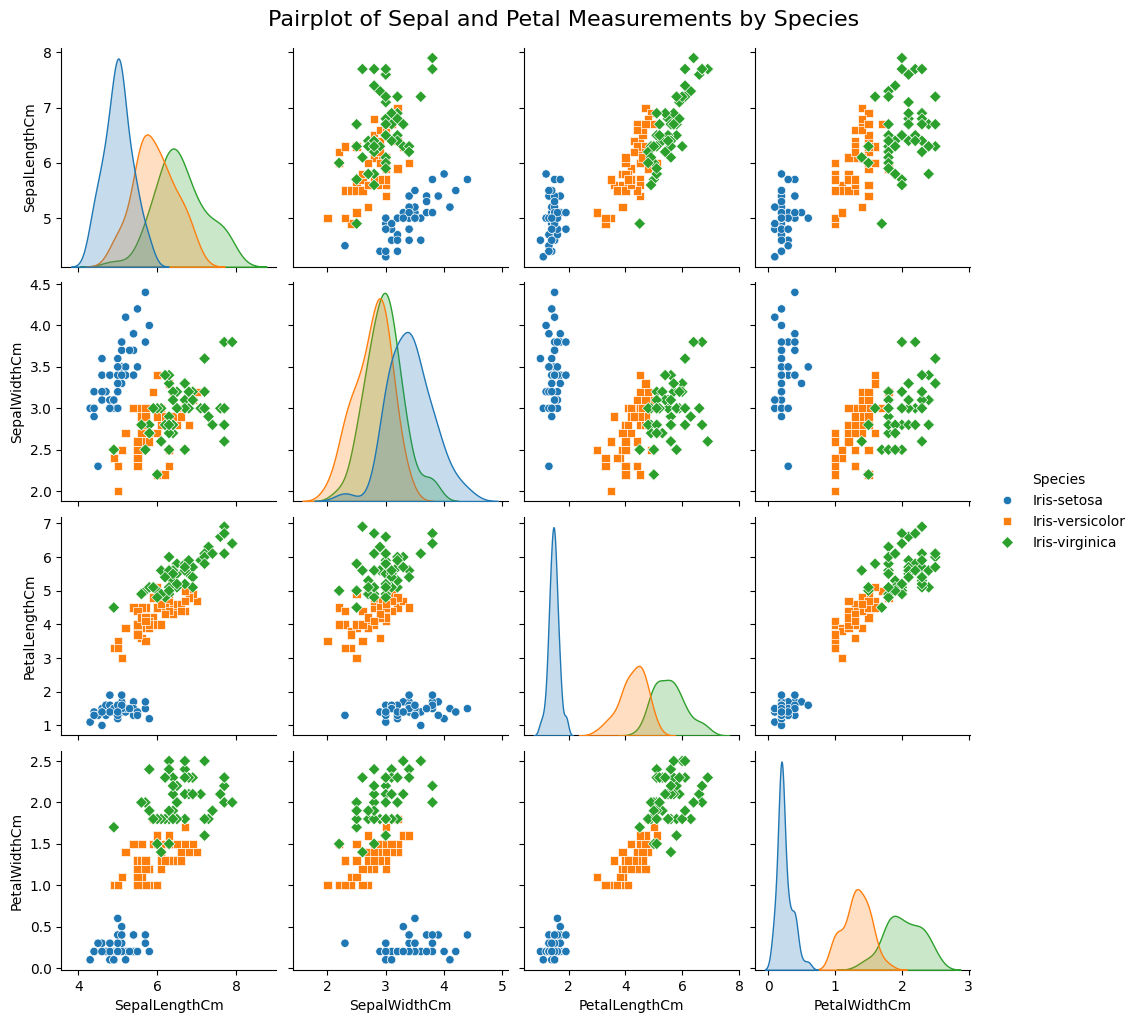

In [11]:
sns.pairplot(df, hue='Species', markers=["o", "s", "D"])
plt.suptitle('Pairplot of Sepal and Petal Measurements by Species', fontsize=16, y=1.02)
plt.show()

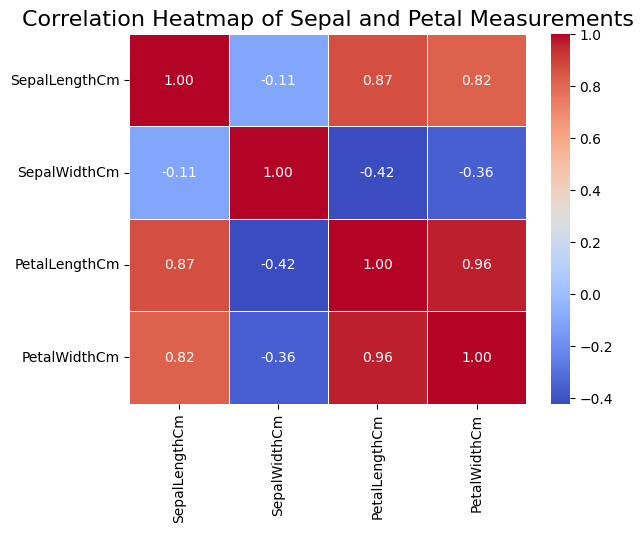

In [12]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Sepal and Petal Measurements', fontsize=16)
plt.show()

as we mentioned previously, sepal length, petal length and width have high correlation also, petal length and patal width correlated to each other

In [13]:
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score


In [14]:
X=df.drop('Species', axis=1)
Y=df['Species']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y,shuffle=True)

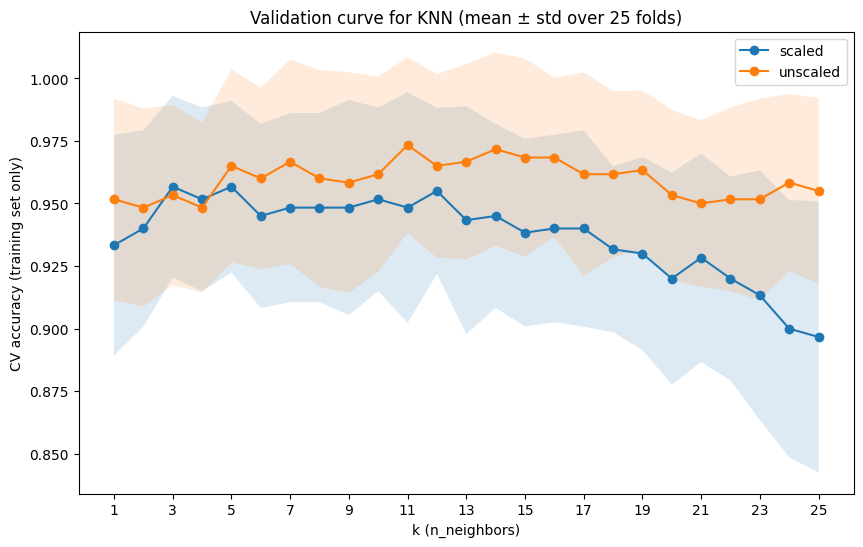

In [15]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
k_values = range(1, 26)

def knn_pipeline(k, scaled=True):
    steps = ([("scaler", StandardScaler())] if scaled else [])
    return Pipeline(steps + [("knn", KNeighborsClassifier(n_neighbors=k))])

results = {}
for scaled in (True, False):
    means, stds = [], []
    for k in k_values:
        s = cross_val_score(knn_pipeline(k, scaled), X_train, Y_train, cv=cv)
        means.append(s.mean()); stds.append(s.std())
    results[scaled] = (np.array(means), np.array(stds))

plt.figure(figsize=(10, 6))
for scaled, label in ((True, "scaled"), (False, "unscaled")):
    m, s = results[scaled]
    plt.plot(list(k_values), m, marker="o", label=label)
    plt.fill_between(list(k_values), m - s, m + s, alpha=0.15)
plt.xlabel("k (n_neighbors)")
plt.ylabel("CV accuracy (training set only)")
plt.title("Validation curve for KNN (mean ± std over 25 folds)")
plt.xticks(range(1, 26, 2))
plt.legend()
plt.show()

In [16]:
use_scaling = results[True][0].max() >= results[False][0].max()
means = results[use_scaling][0]
# highest CV accuracy; ties go to the larger k (smoother decision boundary)
best_k = max(k for k, m in zip(k_values, means) if np.isclose(m, means.max()))
print(f"scaling: {use_scaling} | best k: {best_k} | CV accuracy: {means.max():.3f}")

scaling: False | best k: 11 | CV accuracy: 0.973


train accuracy: 0.975
test accuracy:  0.967

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



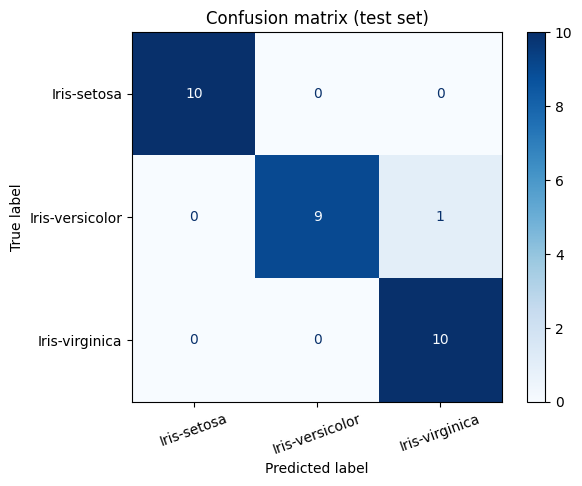

In [17]:
final_model = knn_pipeline(best_k, use_scaling).fit(X_train, Y_train)
pred = final_model.predict(X_test)

print("train accuracy:", round(final_model.score(X_train, Y_train), 3))
print("test accuracy: ", round(accuracy_score(Y_test, pred), 3))
print()
print(classification_report(Y_test, pred))

ConfusionMatrixDisplay.from_predictions(Y_test, pred, cmap="Blues", xticks_rotation=20)
plt.title("Confusion matrix (test set)")
plt.show()